In [ ]:
!pip install rawpy
import rawpy
from google.colab import drive
from tqdm.notebook import tqdm

import imageio
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display
import PIL as Image
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import sklearn.metrics as metrics

from pathlib import Path
import joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.2 MB/s eta 0:00:00


In [ ]:
def pre_summary(long,k):
    central_moments = np.array(list(map(lambda n :np.mean((long - np.mean(long))**n)/(np.std(long)**n),range(2,k+1))))
    raw_moments = np.array(list(map(lambda n :np.mean(long**n)/(np.std(long)**n),range(1,k+1))))
    extreme = np.array([max(long)-min(long),max(long)-raw_moments[0],min(long)-raw_moments[0]])
    summary = np.concatenate((central_moments,raw_moments,extreme),axis = 0)

    return(summary)

def image_summary(image, k = 3):
    pixels = image.flatten().tolist() # flattens the image into a long list
    reds   = np.array(pixels[0::3])
    greens = np.array(pixels[1::3]) # seperates each color into its own list
    blues  = np.array(pixels[2::3])
    red_summary = pre_summary(reds, k)
    blue_summary = pre_summary(blues, k)
    green_summary = pre_summary(greens, k)
    summary = np.concatenate((red_summary,blue_summary,green_summary),axis = 0) # returns the 3*k moments

    return(summary)


In [ ]:
def grey_if_true(image, grey):
    if not grey:
        return image
    elif grey:
        grey_single = image.mean(axis=2, keepdims=True)
        grey_3channel = np.repeat(grey_single, 3, axis=2).astype(image.dtype)
        return grey_3channel


In [ ]:
def show_predictions(img, model ,slice_factor = 1, size = 224, M=3):

    # SLICING THE IMAGE, just downscaling
    img = img[::slice_factor, ::slice_factor]

    vertical_slices, horizontal_slices = get_slices(img,size)
    K,N = (len(vertical_slices),len(horizontal_slices))

    k = 0
    long_stack = []
    while k<(K-1):
        n = 0

        wide_stack = []
        while n<(N-1):
            im = img[vertical_slices[k],horizontal_slices[n]]
            summary = image_summary(im, k = M)
            out = grey_if_true(im,not bool(model.predict([summary])[0]))
            wide_stack.append(out)
            n+=1
        long_stack.append(np.concatenate(wide_stack,axis = 1))
        k+=1
    return(np.concatenate(long_stack, axis = 0))



In [ ]:
def get_slices(rgb,size):
    # DEFINES THE SUBSETS
    height = rgb.shape[0]
    width = rgb.shape[1]

    vertical_slices = []
    horizontal_slices = []

    K = height//size + 1
    for k in range(K):
        t = slice(k*size,min([(k+1)*size,height-1]))
        vertical_slices.append(t)

    N = width//size + 1
    for n in range(N):
        t = slice(n*size,min([(n+1)*size,width-1]))
        horizontal_slices.append(t)

    return (vertical_slices,horizontal_slices)


# Labeling the Images
This function allows the user to label subimages of an image that is imported.
- `size` allows the user to set the number of pixels of the the sidelength of the square subimage.
- `slice_factor` "zooms in" by crudely replaceing every n by n square with 1 of the pixels within it. This is used so that the images can be shrunken easily and speeds up the labeling process.
When labeling the user enters:
- `y` if empty
- `n` if not empty
- `b` to go back and delete the last label if there was a mistake.
- `c` to stop labeling early

In [ ]:
def label_subimages(img, size = 224,slice_factor = 1, model = None):
    using_model = model is not None

    # SLICING THE IMAGE, just downscaling
    img = img[::slice_factor, ::slice_factor]

    vertical_slices, horizontal_slices = get_slices(img,size)
    K = len(vertical_slices)
    N = len(horizontal_slices)


    # LABEL THE SUBIMAGES

    image_list = []
    label_list = []
    prediction = True
    label = ""
    k = 0
    while k<(K-1):
        n = 0
        while n<(N-1):
            clear_output(wait=True)
            plt.clf()
            im = img[vertical_slices[k],horizontal_slices[n]]
            if using_model:
                summary = image_summary(im, k = M)
                prediction = bool(model.predict([summary])[0])
                im = grey_if_true(im,not prediction)
                if prediction == False:
                    image_list.append(im)
                    label_list.append(0)


            if (not using_model or prediction == True):
                plt.axis("off")
                plt.imshow(im)
                plt.show()

                print(f"prediction{prediction}")

                print(f"({k},{n}) image # {k*(N-1)+n +1}/{(N-1)*(K-1)}, len:{len(image_list)}")
                label = input("Is this empty(y/n)?")

                # USER INPUT SECTION

                if label == "c":
                    break
                elif label in ["y","n"]:
                    image_list.append(im)
                    n+=1
                    if label == "y":
                        label_list.append(0)
                    elif label == "n":
                        label_list.append(1)
                elif label == "b":
                    if n>=1:
                        n-=1
                    elif n==0 and k != 0:
                        k-=1
                        n = N-2
                    else:
                        continue
                    image_list.pop()
                    label_list.pop()
                    continue

            else:
                n+=1

        if label == "c":
            break
        k+=1


    # STACKS ALL THE LABEL IMAGES AND SAVES AS .npz FILE
    sub_images = np.stack(image_list, axis = 0)
    sub_image_labels = np.array(label_list)
    print("done")

    #np.savez(f'data/Labeled Subimages/labeled_subimages:{filename}.npz', images=sub_images, labels=sub_image_labels)
    np.savez(f'/content/drive/MyDrive:Session1Non.npz', images=sub_images, labels=sub_image_labels)

## Running the image labeling

In [ ]:
def raw_to_rgb(raw_img: os.path) -> np.float32:
  # Open the RAW image file using rawpy
  with rawpy.imread(raw_img) as raw:
      # Post-process the RAW image to an RGB format
      rgb = raw.postprocess(
          use_camera_wb=True,
          no_auto_bright=True,
          output_color=rawpy.ColorSpace.sRGB
        )

  return rgb

In [ ]:
drive.mount('/content/drive')

labeled_images = np.load('/content/drive/MyDrive/MacroInvertebrates Project/Save States/labeled_images.npy')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


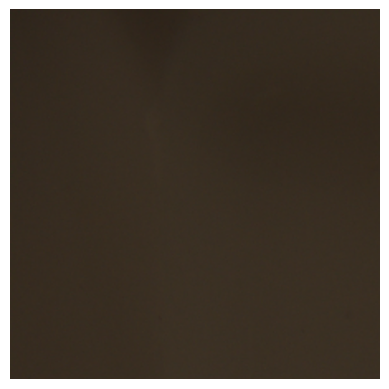

predictionTrue


KeyboardInterrupt: Interrupted by user

In [ ]:
for path, species, count in labeled_images:
    image = raw_to_rgb(path)
    label_subimages(
        image,
        size=224,
        slice_factor=2
    )
    del image  # free RAM

# Saving and Organizing the Data

- Each time the labeling function is run, it makes a new npz folder for that specific image.
- All of the sessions of labeling are combined here into one big npz folder. using_model

In [ ]:
labeled_image_source = 'data/Labeled Subimages/'
folder_path = Path(labeled_image_source)
labeled = [f.name[:-4] for f in folder_path.iterdir() if (f.is_file() and f.name[-4:]=='.npz')]
# COMBINES THE LABELED DATA INTO ONE FILE


In [ ]:
#labeled = ["5B7A9568","5B7A9558","5B7A9562"]
datasets = [np.load(f'{labeled_image_source}{x}.npz') for x in labeled]
images = [dataset['images'] for dataset in datasets]
labels = [dataset['labels'] for dataset in datasets]
images = np.concatenate(images,axis = 0)
labels = np.concatenate(labels,axis = 0)

# SAVES THE FILE
np.savez('full_data.npz', images=images, labels=labels)

In [ ]:
# READS THE COMBINED FILE
data = np.load('full_data.npz')
plt.imshow(data['images'][np.where(data['labels'] !=0)[0][0]])
data['images'].shape

# Naive Bayes
- I flattened the images into lists of color values so [r1,g1,b1,r2,g2,b2,...]
- then seperated by color into 3 lists.
- In order to have a scalable way of using summary statistics I just made a function that would take the first k raw moments and central moments and the difference between the minimum value and maximum value for each of the colors.
- k is the number of moments to take so you end up with 3k features for naive bayes.
- It seemed like k higher than 3 made the naive model worse.


In [ ]:
M = 3 # number of raw moments to use as predictors

summarylist = np.array([image_summary(x, k = M) for x in data['images']])

original_indices = np.arange(len(summarylist))
X_train, X_test, y_train, y_test, index_train, index_test= train_test_split(summarylist, data['labels'],original_indices, test_size=0.2)
model = GaussianNB()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

NameError: name 'data' is not defined

## Testing the Model
- I saved the indexes from the original data of the test set.
- This allowed me to look at the image of the errors.
- What I noticed was that every time it would make a mistake it would be on the corner or the edge of the box.
- Probabily because of the variance in light.
- This is pretty good though given that I only labeled 3 images.

In [ ]:

predictions = model.predict(X_train)
con_mat = metrics.confusion_matrix(y_train,predictions)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=model.classes_)

disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:

predictions = model.predict(X_test)

con_mat = metrics.confusion_matrix(y_test,predictions)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=model.classes_)

disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
# The indexes of the errors in the test set.
errors = np.where(y_test != predictions)
print(errors[0].shape)

In [ ]:
place = errors[0][0]
plt.imshow(data['images'][index_test[place]])
print(f" predicted:{predictions[place]}\ntrue value:{data['labels'][index_test[place]]}")

In [ ]:
first_image = show_predictions("data/Nov12/",files[11],model,size = 224,slice_factor = 2,M=M)
plt.axis(False)
plt.imshow(first_image)

In [ ]:
 # save the naive bayes model

joblib.dump(model, 'naive_bayes_model.pkl')

In [ ]:
# import the naive bayes model

model = joblib.load('naive_bayes_model.pkl')